## Cerebellar neuron models, using Brian2

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

This notebook presents current injection simulations of E-GLIF neuron models published in [Geminiani et al., 2019](https://doi.org/10.3389/fncom.2019.00035) and [Lorenzi et al., 2023](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1011434).

The **E-GLIF** describes the evolution of the membrane potential, $V(t)$, of a single compartment of a neuron membrane and two intrinsic currents: adaptive current, $I_{a}(t)$, and depolarizing spike-triggered current, $I_{d}(t)$. It consists of a system of *three differential equations*:
\begin{align}
    \left\{
    \begin{array}{l}
        \frac{dV_m}{dt} = \frac{1}{C_m} \left( \frac{Cm}{\tau_m}(V_m(t) - E_L) -I_a(t) + I_d(t) + I_e(t)+I_s \right) \\
        \frac{dI_a}{dt} = k_a(V_m(t) - E_L) - k_2 I_a(t) \\
        \frac{dI_d}{dt} = - k_1I_d(t)
    \end{array}
    \right.
\end{align}

where:
$C_m$ = membrane capacitance;

$\tau_m$ = membrane time constant;

$E_L$ = resting potential;

$I_e$ = endogenous current modeling the net contribution of depolarizing ionic currents generating autorhythmicity;

$I_s$ = external stimulation current;

$k_a$ and $k_2$ = adaptation constants;

$k_1$ = decay rate.

If the neuron is not in the refractory interval $t_{ref}$, a spike is generated stochastically at $t_{spk}$, based on a point process that depends on the escape rate function $\lambda(t)$ :

\begin{equation}
\lambda(t) = \lambda_0 \exp {\frac{V_m(t)-V_{th}}{\tau_V}}
\end{equation}

where:

$V_{th}$ = threshold potential;

$\lambda_0$ and $\tau_V$ = escape rate parameters;

Spikes do not strictly occur when the potential reaches the threshold: but they occur with higher probability if the membrane potential is near the threshold, depending on the parameters $\lambda_0$ and $\tau_V$ that define the minimum distance from threshold corresponding to the maximum probability of having a spike.


When a spike occurs, a series of reset conditions is triggered:
\begin{align}
    \left\{
    \begin{array}{l}
        V \rightarrow V_\textit{reset} \\
        I_a \rightarrow I_a + A2 \\
        I_d \rightarrow A1
    \end{array}
    \right.
\end{align}

where:

$V_\textit{reset}$ = reset potential;

$A_1$ and $A_2$ = model currents update constants.

For more details, see: [Mihalaş and Niebur, 2009](https://direct.mit.edu/neco/article-abstract/21/3/704/7389/A-Generalized-Linear-Integrate-and-Fire-Neural?redirectedFrom=fulltext), [Gerstner et al., 2014](https://scholar.google.it/scholar?hl=en&as_sdt=0%2C5&q=Gerstner%2C+W.%2C+Kistler%2C+W.+M.%2C+Naud%2C+R.%2C+and+Paninski%2C+L.+%282014%29.+Neuronal+Dynamics%3A+From+single+neurons+to+networks+and+models+of+cognition.+Cambridge%3A+Cambridge+University+Press.+doi%3A+10.1017%2FCBO9781107447615&btnG=), [Geminiani et al.,2018](https://doi.org/10.3389/fninf.2018.00088) and [Geminiani et al., 2019](https://doi.org/10.3389/fncom.2019.00035).

In this notebook neurons are driven by **current injection**.

In [1]:
#%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
import sys
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [3]:
from ntmf.neurons import setting_EGLIF_simulation_Brian_Vmin_membrane_fluc
from utils.Plots_helper import *


In [4]:
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '-figs.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig) 

In [5]:
saving_plots = True       # set to True/False to save/not save the plots

In [6]:
# Explicitly defining the intensity of the current
amp = .3        #nA 
fig_name = f'cerebellar_neurons_curr_inj_{amp}_nA_GoC_fluc.pdf'

### Defining the current injection protocol: $I_s$

In [7]:
# Defining the delay and the duration of the stimulus (step current injection)
s_delay = 2000        # ms
s_duration = 1000     # ms
dt = 0.1                # ms

stim_delay = s_delay/dt 
stim_duration = s_duration/dt

# Explicitly defining the time
Time = 5000          # ms
time = np.arange(0,Time+dt,dt)

In [8]:
data_folder = '../neuron_models/EGLIF'
idx = 0 # in this case only one model per cell type is provided

In [9]:
# Defining the current injection structure
stim_t_start = int(stim_delay * dt)
stim_t_end = int(stim_duration * dt + stim_t_start)
stim_unit = 1. * b2.ms
stim_amplitude = amp * b2.nA
stim_time = Time * b2.ms

# Setting up the step current injection protocol
tmp_size = 2 + stim_t_end  
tmp = np.zeros((tmp_size, 1)) * b2.amp
tmp[stim_t_start: stim_t_end + 1, 0] = stim_amplitude
curr_array = b2.TimedArray(tmp, dt=1. * stim_unit).values.flatten()  # to solve the issue with dimention of the current vector
current_timed_array = b2.TimedArray(curr_array * b2.amp, dt=stim_unit)

### Setting up the neuron model

#### Golgi Cells

In [10]:
neuron_model = 'GoC' 
G, params = setting_EGLIF_simulation_Brian_Vmin_membrane_fluc(idx = idx,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'),
                                 curr_inj = current_timed_array)

#G, params = setting_EGLIF_simulation_Brian_Vmin_membrane_fluc(
#    neuron_model,
#    os.path.join(data_folder, neuron_model + '.json'),
#    idx=idx,
#    curr_inj=current_timed_array,
#)

# Defineing what happens at the event to deal with Vmin
G.run_on_event('vmin_event', 'V = Vmin')
print(f'Initial membrane potential: {G.V}')

neuron model: GoC
Initial membrane potential: <neurongroup.V: array([-73.58736641]) * mvolt>


In [11]:
print(f'Initial membrane potential: {G.V}')

Initial membrane potential: <neurongroup.V: array([-73.58736641]) * mvolt>


In [12]:
# to explore what's in the G (b2.NeuronGroup), use:

#print(dir(G))

#G._refractory
#G.event_codes

### Defining the Monitors (variables to record)

In [13]:
mon = b2.StateMonitor(G, ['V', 'Ia','Id','Ie', 'Is'], record=True)
mon_spike = b2.SpikeMonitor(G)


In [14]:
# to explore what's in the Monitor, use:
# print(dir(mon))
# or for more details
# help(mon)

In [15]:
#print(dir(mon_spike))

### Running the simulation of the GoC neuron model

In [16]:
%%time
b2.run(stim_time, namespace={'external_current': current_timed_array})

CPU times: user 643 ms, sys: 19.9 ms, total: 663 ms
Wall time: 728 ms


### Plotting the results

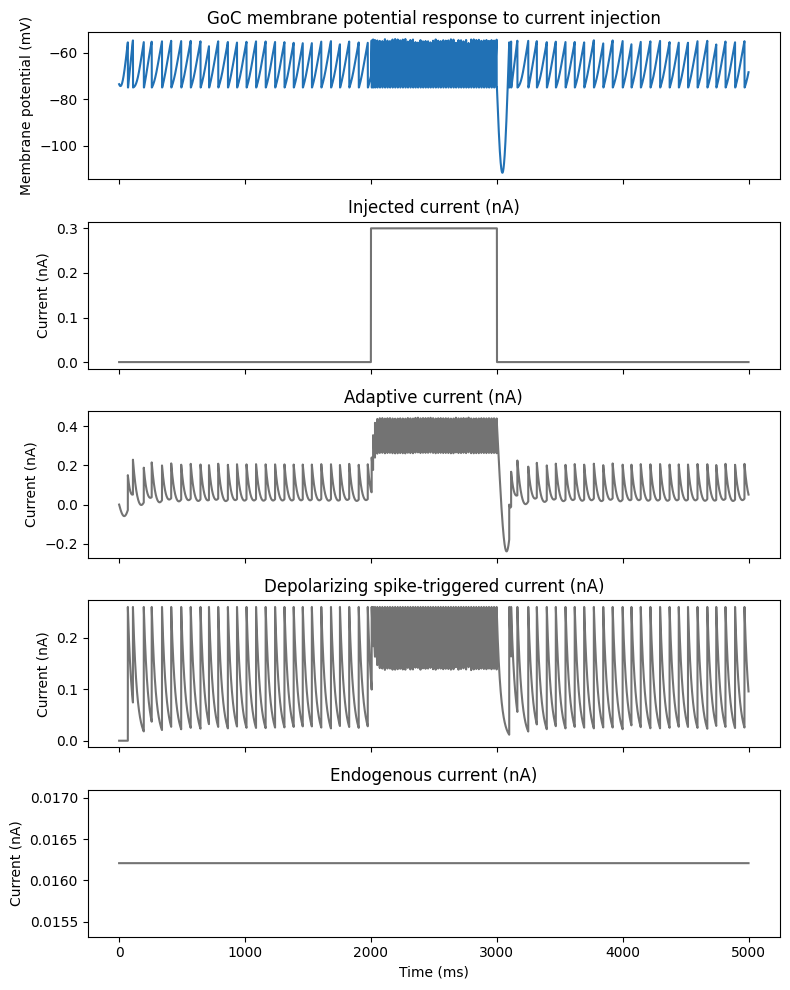

In [17]:
ax, fig = plotting_state_monitor_variables(mon = mon,
                                       neuron_model = neuron_model)
figs.append(fig)

Injected current: 0.3 nA
Average GrC firing rate: 51.00 Hz


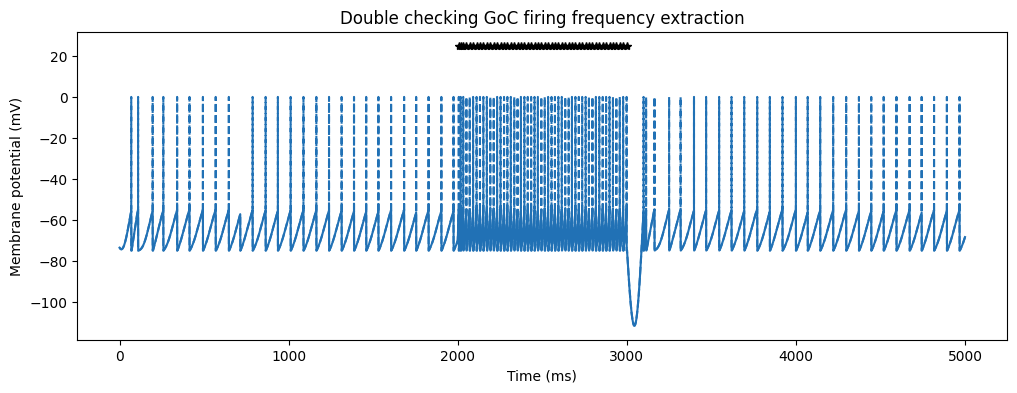

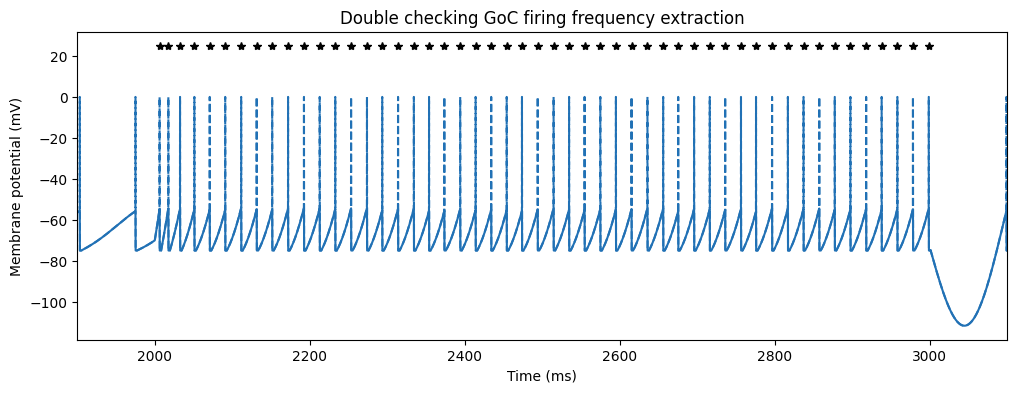

In [18]:
mask = (mon_spike.t >= stim_t_start* b2.ms) & (mon_spike.t < stim_t_end* b2.ms)
n_spikes_interval = mask.sum() 

# the voltage in the get_pretty_voltage
# needs to be tuned depending on the neuron type
v_plot = get_pretty_voltage(mon.V[0], -57)

print(f"Injected current: {amp} nA")

stim_duration = s_duration * b2.ms

if s_duration == 1000:
    print(f"Average GrC firing rate: {n_spikes_interval / b2.Hz:.2f} Hz")

fig = plt.figure(figsize=(12,4))
plt.plot(mon.t / b2.ms, mon.V[0] / b2.mV, color=color_palette[neuron_model])
plt.plot(mon_spike.t[mask] / b2.ms, np.ones(n_spikes_interval) * (25), '*k')
plt.plot(mon.t / b2.ms, v_plot / b2.mV, '--', color=color_palette[neuron_model])
#plt.xlim(1900,3100)
plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')
plt.title(f'Double checking {neuron_model.split("_")[0]} firing frequency extraction')
figs.append(fig)

fig = plt.figure(figsize=(12,4))
plt.plot(mon.t / b2.ms, mon.V[0] / b2.mV, color=color_palette[neuron_model])
plt.plot(mon_spike.t[mask] / b2.ms, np.ones(n_spikes_interval) * (25), '*k')
plt.plot(mon.t / b2.ms, v_plot / b2.mV, '--', color=color_palette[neuron_model])
plt.xlim(1900,3100)
plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')
plt.title(f'Double checking {neuron_model.split("_")[0]} firing frequency extraction')
figs.append(fig)

In [19]:
if saving_plots == True:
    save_figs(fig_path, fig_name, figs)